# Simple Linear Regression — Complete Guide

This notebook covers **Simple Linear Regression** end-to-end with equations, cost function, gradient descent (convergence algorithm), real-world examples, worked numerical examples, and all associated diagrams/graphs generated using `matplotlib`, `seaborn`, and `numpy`.

## Table of Contents
1. What is Simple Linear Regression? (with real-world examples)
2. The Equation (Hypothesis Function) — worked example
3. Residuals (Errors) — numerical demo
4. Cost Function (MSE) — step-by-step calculation
5. Gradient Descent — Convergence Algorithm (with intuition)
6. Learning Rate Effects
7. Convergence Plot
8. Closed-Form Solution (Normal Equation / OLS) — hand-calculated example
9. Evaluation Metrics (R², MAE, MSE, RMSE, Adjusted R²)
10. Assumptions of Linear Regression
11. **End-to-end Example: Salary Prediction from Years of Experience**
12. **Comparison with sklearn**

## Setup — Import Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

np.random.seed(42)

## 1. What is Simple Linear Regression?

Simple Linear Regression models the relationship between **one independent variable (X)** and **one dependent variable (Y)** by fitting a straight line through the data.

**Goal:** Find the best-fit line that predicts Y from X with the minimum possible error.

### Real-World Examples

| Independent Variable (X) | Dependent Variable (Y) | Question |
|---|---|---|
| Years of experience | Salary | How much more do I earn per year of experience? |
| House size (sq ft) | House price | How much does one extra sq ft add to the price? |
| Hours studied | Exam score | How does an extra hour of study affect my score? |
| Advertising spend | Sales revenue | How much revenue per ₹1 of ad spend? |
| Temperature | Ice cream sales | How does temperature affect demand? |

### Intuition — Why a Line?

In many real situations, when X increases, Y tends to change **proportionally**. A straight line is the simplest mathematical object that captures this. If a curve fits better, we move on to polynomial or non-linear regression — but the line is our starting point.

Let's generate synthetic data to visualize this.

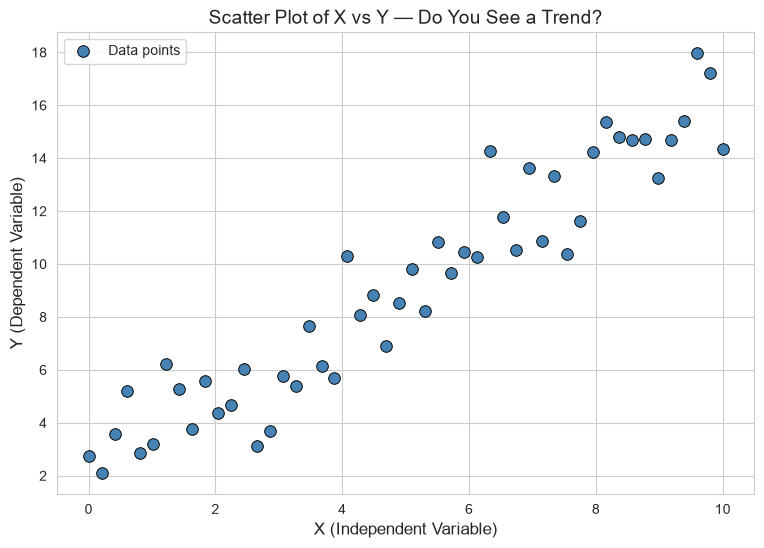

Number of data points: 50
X range: [0.00, 10.00]
Y range: [2.10, 17.97]


In [30]:
m = 50
X = np.linspace(0, 10, m)
true_theta0, true_theta1 = 2.0, 1.5
noise = np.random.normal(0, 1.5, m)
y = true_theta0 + true_theta1 * X + noise

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X, y=y, s=70, color='steelblue', edgecolor='black', label='Data points')
plt.title('Scatter Plot of X vs Y — Do You See a Trend?')
plt.xlabel('X (Independent Variable)')
plt.ylabel('Y (Dependent Variable)')
plt.legend()
plt.show()

print(f'Number of data points: {m}')
print(f'X range: [{X.min():.2f}, {X.max():.2f}]')
print(f'Y range: [{y.min():.2f}, {y.max():.2f}]')

## 2. The Equation (Hypothesis Function)

$$h_\theta(x) = \theta_0 + \theta_1 x$$

Or equivalently:

$$\hat{y} = \beta_0 + \beta_1 x$$

Where:
- **θ₀ (β₀)** = intercept — value of Y when X = 0 (where line crosses Y-axis)
- **θ₁ (β₁)** = slope — how much Y changes when X increases by 1 unit
- **ŷ** = predicted value ("y-hat")
- **x** = input feature

### Worked Example — Salary Prediction

Suppose we fit a model for salary vs years of experience and get:

$$\hat{\text{Salary}} = 30{,}000 + 5{,}000 \times \text{Years}$$

**Interpretation:**
- θ₀ = 30,000 → A person with 0 years of experience earns ₹30,000 (base salary)
- θ₁ = 5,000 → Each additional year of experience adds ₹5,000 to salary
- For 4 years of experience: ŷ = 30,000 + 5,000 × 4 = **₹50,000**

C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


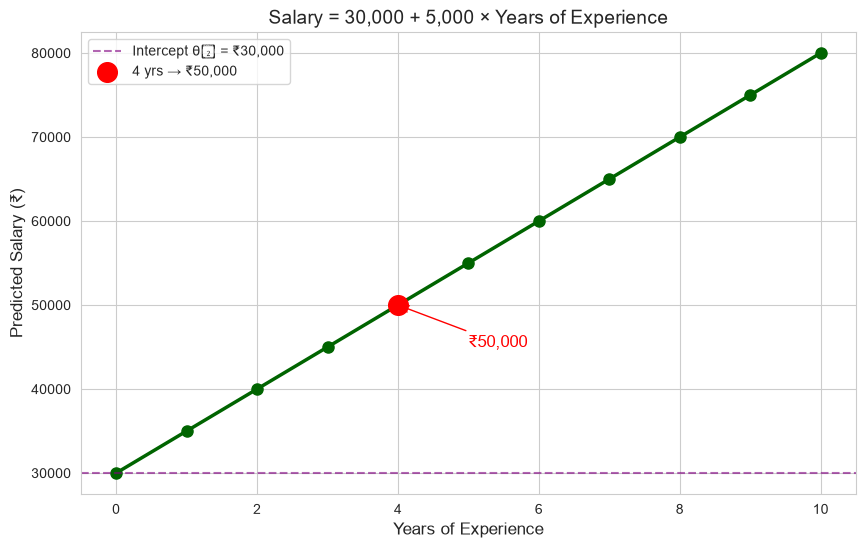

  0 years of experience → Predicted salary = ₹30,000
  2 years of experience → Predicted salary = ₹40,000
  5 years of experience → Predicted salary = ₹55,000
  10 years of experience → Predicted salary = ₹80,000


In [31]:
# Salary example — visualize it
years = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
predicted_salary = 30000 + 5000 * years

plt.figure(figsize=(10, 6))
plt.plot(years, predicted_salary, 'o-', color='darkgreen', linewidth=2.5, markersize=8)
plt.axhline(y=30000, color='purple', linestyle='--', alpha=0.6, label='Intercept θ₀ = ₹30,000')

# Highlight the 4-year prediction
plt.scatter([4], [50000], color='red', s=200, zorder=5, label='4 yrs → ₹50,000')
plt.annotate('₹50,000', xy=(4, 50000), xytext=(5, 45000),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')

plt.title('Salary = 30,000 + 5,000 × Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Predicted Salary (₹)')
plt.legend()
plt.show()

for yr in [0, 2, 5, 10]:
    print(f'  {yr} years of experience → Predicted salary = ₹{30000 + 5000*yr:,}')

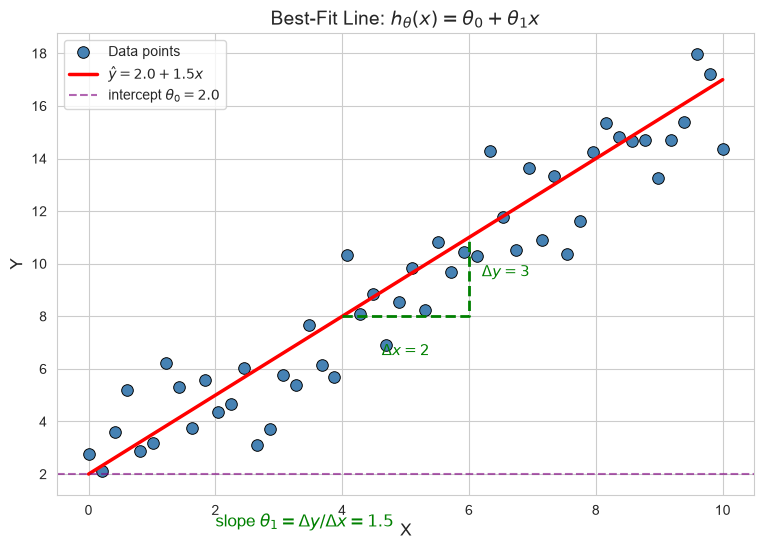

In [32]:
# Plot the best-fit line on our synthetic data
theta0, theta1 = 2.0, 1.5
y_pred = theta0 + theta1 * X

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X, y=y, s=70, color='steelblue', edgecolor='black', label='Data points')
plt.plot(X, y_pred, color='red', linewidth=2.5, label=fr'$\hat{{y}} = {theta0} + {theta1}x$')

# Show slope visually as a triangle
x1, x2 = 4, 6
y1, y2 = theta0 + theta1*x1, theta0 + theta1*x2
plt.plot([x1, x2, x2], [y1, y1, y2], color='green', linewidth=2, linestyle='--')
plt.text((x1+x2)/2, y1 - 1.5, r'$\Delta x = 2$', color='green', fontsize=11, ha='center')
plt.text(x2 + 0.2, (y1+y2)/2, r'$\Delta y = 3$', color='green', fontsize=11)
plt.text(2, 0, r'slope $\theta_1 = \Delta y / \Delta x = 1.5$', color='green', fontsize=12)

plt.axhline(y=theta0, color='purple', linestyle='--', alpha=0.6, label=fr'intercept $\theta_0={theta0}$')

plt.title('Best-Fit Line: $h_\\theta(x) = \\theta_0 + \\theta_1 x$')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 3. Residuals (Errors)

The **residual** for each data point is the vertical distance between the actual value and the predicted value:

$$e_i = y_i - \hat{y}_i$$

- **Positive residual** → actual point is ABOVE the line (model under-predicts)
- **Negative residual** → actual point is BELOW the line (model over-predicts)
- **Zero residual** → perfect prediction (rare)

### Numerical Example

Say the true price of a 1000 sq ft house is ₹50 lakh, but our model predicts ₹48 lakh.

$$e = 50 - 48 = +2 \text{ lakh}$$

The model **under-predicted by 2 lakh** for this house.

In [33]:
# Show residuals numerically for the first 5 points
df_residuals = pd.DataFrame({
    'X': X[:5].round(2),
    'Actual y': y[:5].round(2),
    'Predicted ŷ': y_pred[:5].round(2),
    'Residual e = y - ŷ': (y[:5] - y_pred[:5]).round(2),
    'Squared Residual e²': ((y[:5] - y_pred[:5])**2).round(2)
})
print('First 5 residuals:\n')
print(df_residuals.to_string(index=False))
print(f'\nSum of residuals: {(y - y_pred).sum():.4f}   (should be ~0 for the best-fit line)')
print(f'Sum of squared residuals: {((y - y_pred)**2).sum():.4f}')

First 5 residuals:

   X  Actual y  Predicted ŷ  Residual e = y - ŷ  Squared Residual e²
0.00      2.75         2.00                0.75                 0.56
0.20      2.10         2.31               -0.21                 0.04
0.41      3.58         2.61                0.97                 0.94
0.61      5.20         2.92                2.28                 5.22
0.82      2.87         3.22               -0.35                 0.12

Sum of residuals: -16.9105   (should be ~0 for the best-fit line)
Sum of squared residuals: 101.8284


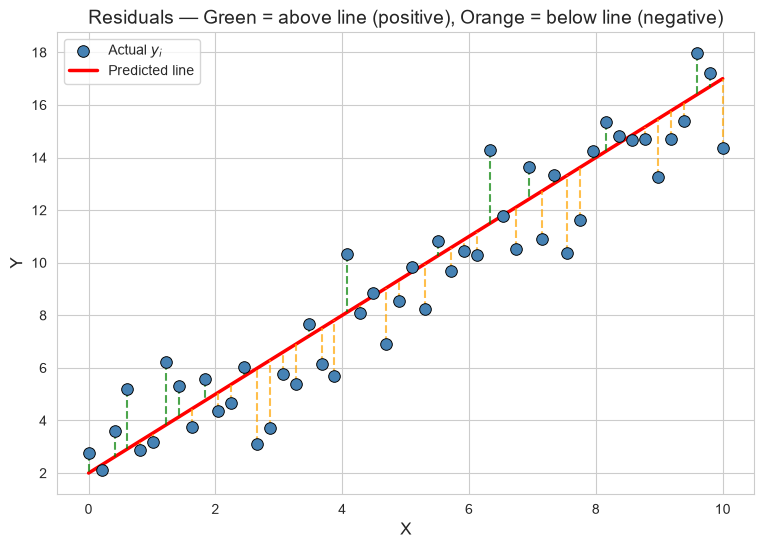

In [34]:
# Visualize residuals
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X, y=y, s=70, color='steelblue', edgecolor='black', label='Actual $y_i$', zorder=3)
plt.plot(X, y_pred, color='red', linewidth=2.5, label='Predicted line')

for xi, yi, ypi in zip(X, y, y_pred):
    color = 'green' if yi > ypi else 'orange'
    plt.plot([xi, xi], [yi, ypi], color=color, linestyle='--', alpha=0.7)

plt.title('Residuals — Green = above line (positive), Orange = below line (negative)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 4. Cost Function (Mean Squared Error)

We measure "how bad" the line is using the **MSE cost function**:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x_i) - y_i \right)^2$$

### Why Squared?

1. **Positive & negative errors don't cancel** — squaring makes all errors positive.
2. **Penalizes big errors more** — an error of 10 contributes 100 to the cost; an error of 2 contributes only 4. This forces the model to avoid large mistakes.
3. **Differentiable everywhere** — unlike absolute value |x|, which has a kink at 0. This lets us use calculus (gradient descent).

### Why 1/2m?

- **1/m** → average across all data points (so cost doesn't grow with sample size)
- **1/2** → convenience factor. When we differentiate x², the 2 comes down, and the 1/2 cancels it, giving cleaner formulas.

**Goal:** Minimize J(θ₀, θ₁).

The cost function is **convex** — one global minimum, no local traps.

In [35]:
# Worked example: compute cost by hand for a small dataset
X_small = np.array([1, 2, 3, 4, 5])
y_small = np.array([2, 4, 5, 4, 5])

# Try theta0=1, theta1=1 → ŷ = 1 + x
t0, t1 = 1, 1
y_hat = t0 + t1 * X_small
errors = y_hat - y_small
squared = errors ** 2

df_calc = pd.DataFrame({
    'x': X_small,
    'y': y_small,
    'ŷ = 1 + x': y_hat,
    '(ŷ - y)': errors,
    '(ŷ - y)²': squared
})
print('Step-by-step cost calculation for θ₀=1, θ₁=1:\n')
print(df_calc.to_string(index=False))

m_small = len(y_small)
cost = (1 / (2 * m_small)) * squared.sum()
print(f'\nSum of squared errors = {squared.sum()}')
print(f'Cost J = (1/2m) × sum = (1/{2*m_small}) × {squared.sum()} = {cost:.4f}')

Step-by-step cost calculation for θ₀=1, θ₁=1:

 x  y  ŷ = 1 + x  (ŷ - y)  (ŷ - y)²
 1  2          2        0         0
 2  4          3       -1         1
 3  5          4       -1         1
 4  4          5        1         1
 5  5          6        1         1

Sum of squared errors = 4
Cost J = (1/2m) × sum = (1/10) × 4 = 0.4000


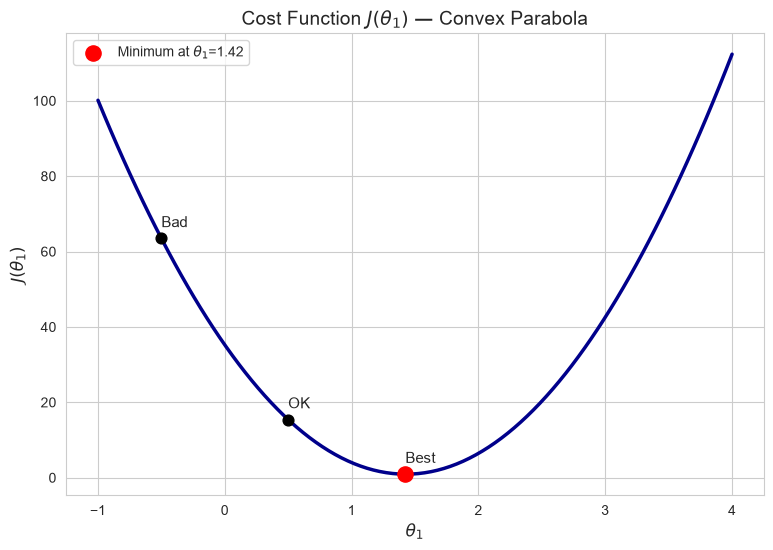

In [36]:
def compute_cost(X, y, theta0, theta1):
    m = len(y)
    predictions = theta0 + theta1 * X
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

# 2D plot: Cost vs theta1 (fixing theta0)
theta1_range = np.linspace(-1, 4, 100)
costs = [compute_cost(X, y, true_theta0, t1) for t1 in theta1_range]

plt.figure(figsize=(9, 6))
plt.plot(theta1_range, costs, color='darkblue', linewidth=2.5)
min_idx = np.argmin(costs)
plt.scatter(theta1_range[min_idx], costs[min_idx], color='red', s=120, zorder=5,
            label=f'Minimum at $\\theta_1$={theta1_range[min_idx]:.2f}')

# Annotate: bad, ok, best
for t1_val, tag in [(-0.5, 'Bad'), (0.5, 'OK'), (theta1_range[min_idx], 'Best')]:
    c = compute_cost(X, y, true_theta0, t1_val)
    plt.scatter(t1_val, c, s=60, color='black', zorder=4)
    plt.annotate(tag, xy=(t1_val, c), xytext=(t1_val, c + 3), fontsize=11)

plt.title(r'Cost Function $J(\theta_1)$ — Convex Parabola')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$J(\theta_1)$')
plt.legend()
plt.show()

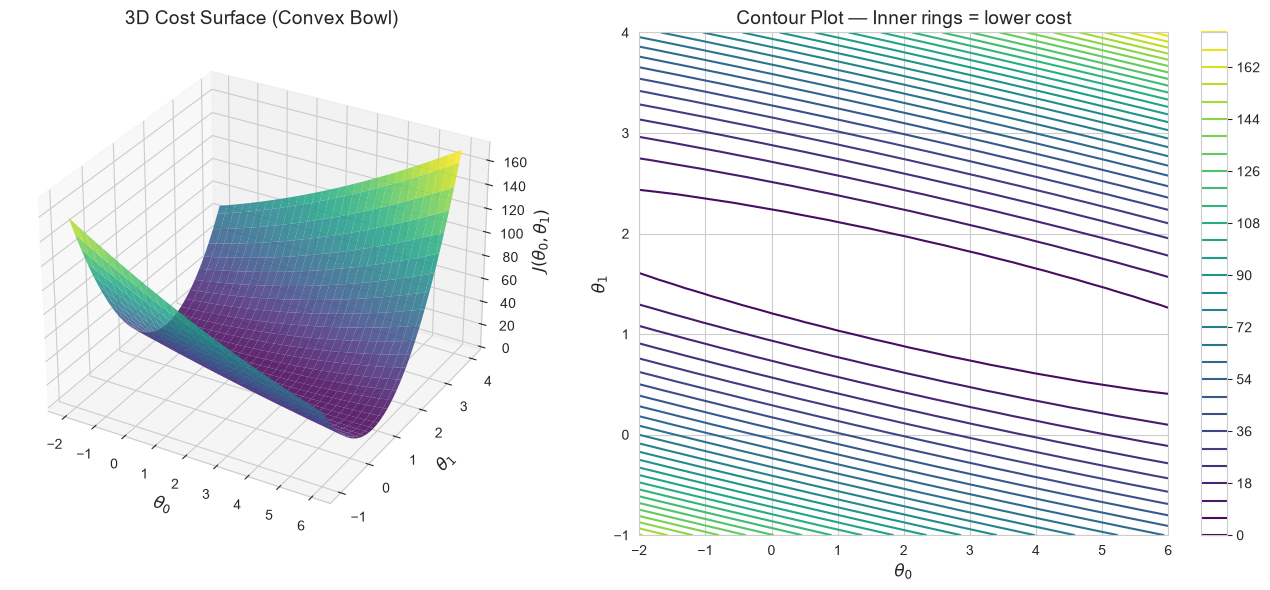

KEY INSIGHT: The bowl has ONE minimum. Any starting point,
with a proper learning rate, will roll down to the same point.


In [37]:
# 3D Cost Function Surface (bowl shape)
theta0_vals = np.linspace(-2, 6, 60)
theta1_vals = np.linspace(-1, 4, 60)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = compute_cost(X, y, T0[i, j], T1[i, j])

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(T0, T1, J_vals, cmap=cm.viridis, alpha=0.85, edgecolor='none')
ax1.set_xlabel(r'$\theta_0$')
ax1.set_ylabel(r'$\theta_1$')
ax1.set_zlabel(r'$J(\theta_0, \theta_1)$')
ax1.set_title('3D Cost Surface (Convex Bowl)')

ax2 = fig.add_subplot(1, 2, 2)
cp = ax2.contour(T0, T1, J_vals, levels=30, cmap=cm.viridis)
ax2.set_xlabel(r'$\theta_0$')
ax2.set_ylabel(r'$\theta_1$')
ax2.set_title('Contour Plot — Inner rings = lower cost')
plt.colorbar(cp, ax=ax2)

plt.tight_layout()
plt.show()

print('KEY INSIGHT: The bowl has ONE minimum. Any starting point,')
print('with a proper learning rate, will roll down to the same point.')

## 5. Gradient Descent — Convergence Algorithm

Gradient Descent iteratively updates θ₀ and θ₁ to reach the minimum of J.

### The Intuition — Rolling Down a Hill

Imagine standing on the surface of the cost bowl blindfolded. Your goal is to reach the lowest point.

1. Feel the slope under your feet (compute the gradient).
2. Take a step in the **opposite direction of the slope** (steepest descent).
3. The step size is controlled by the **learning rate α**.
4. Repeat until the ground is flat (gradient ≈ 0).

### Update Rules

Repeat until convergence:

$$\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0}$$

$$\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}$$

**Important:** Both parameters must be updated **simultaneously** using the OLD values on the right side.

### Partial Derivatives (derivation sketch)

Starting from $J = \frac{1}{2m} \sum (h_\theta(x_i) - y_i)^2$ and applying the chain rule:

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x_i) - y_i)$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x_i) - y_i) \cdot x_i$$

The extra factor of x in the second one is because $\theta_1$ is multiplied by x in the hypothesis.

In [38]:
def gradient_descent(X, y, alpha=0.01, iterations=1000, theta0=0.0, theta1=0.0, verbose=False):
    m = len(y)
    cost_history = []
    theta_history = []

    for i in range(iterations):
        predictions = theta0 + theta1 * X
        error = predictions - y

        d_theta0 = (1 / m) * np.sum(error)
        d_theta1 = (1 / m) * np.sum(error * X)

        theta0 -= alpha * d_theta0
        theta1 -= alpha * d_theta1

        cost_history.append(compute_cost(X, y, theta0, theta1))
        theta_history.append((theta0, theta1))

        if verbose and i in [0, 1, 5, 10, 50, 100, iterations-1]:
            print(f'  Iter {i:4d} | θ₀={theta0:.4f}, θ₁={theta1:.4f}, Cost={cost_history[-1]:.4f}')

    return theta0, theta1, cost_history, theta_history

print('Gradient Descent progression:\n')
final_theta0, final_theta1, cost_hist, theta_hist = gradient_descent(X, y, alpha=0.02, iterations=500, verbose=True)
print(f'\nFinal θ₀ = {final_theta0:.4f}')
print(f'Final θ₁ = {final_theta1:.4f}')
print(f'Final Cost = {cost_hist[-1]:.4f}')

Gradient Descent progression:

  Iter    0 | θ₀=0.1832, θ₁=1.1613, Cost=6.2341
  Iter    1 | θ₀=0.2467, θ₁=1.5222, Cost=1.8305
  Iter    5 | θ₀=0.3075, θ₁=1.6791, Cost=1.3406
  Iter   10 | θ₀=0.3524, θ₁=1.6740, Cost=1.3202
  Iter   50 | θ₀=0.6715, θ₁=1.6262, Cost=1.1899
  Iter  100 | θ₀=0.9897, θ₁=1.5786, Cost=1.0861
  Iter  499 | θ₀=1.9492, θ₁=1.4351, Cost=0.9311

Final θ₀ = 1.9492
Final θ₁ = 1.4351
Final Cost = 0.9311


C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


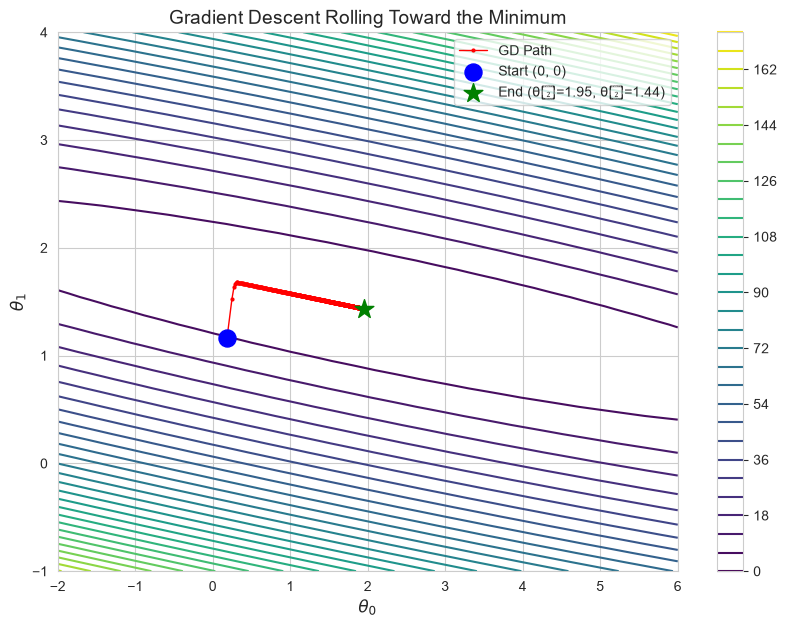

In [39]:
# Visualize Gradient Descent path on the contour plot
theta0_path = [t[0] for t in theta_hist]
theta1_path = [t[1] for t in theta_hist]

fig, ax = plt.subplots(figsize=(10, 7))
cp = ax.contour(T0, T1, J_vals, levels=30, cmap=cm.viridis)
ax.plot(theta0_path, theta1_path, 'r.-', markersize=4, linewidth=1, label='GD Path')
ax.scatter(theta0_path[0], theta1_path[0], color='blue', s=150, zorder=5, label='Start (0, 0)')
ax.scatter(theta0_path[-1], theta1_path[-1], color='green', s=200, marker='*', zorder=5,
           label=f'End (θ₀={theta0_path[-1]:.2f}, θ₁={theta1_path[-1]:.2f})')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title('Gradient Descent Rolling Toward the Minimum')
plt.colorbar(cp, ax=ax)
ax.legend()
plt.show()

## 6. Learning Rate (α) — The Most Important Hyperparameter

The learning rate controls **how big a step** gradient descent takes each iteration.

- **α too small** → correct direction, but painfully slow. Takes forever to converge.
- **α too large** → each step overshoots the minimum. Cost oscillates or **diverges to infinity**.
- **α just right** → smooth, fast convergence.

### Practical Tips
- Start with α = 0.01 or 0.001 and adjust.
- Try values like 0.001, 0.003, 0.01, 0.03, 0.1, 0.3 (roughly 3× spacing).
- Plot cost vs iterations — if it goes UP, α is too big; if it barely moves, α is too small.
- For deep learning, adaptive optimizers (Adam, RMSprop) adjust α automatically.

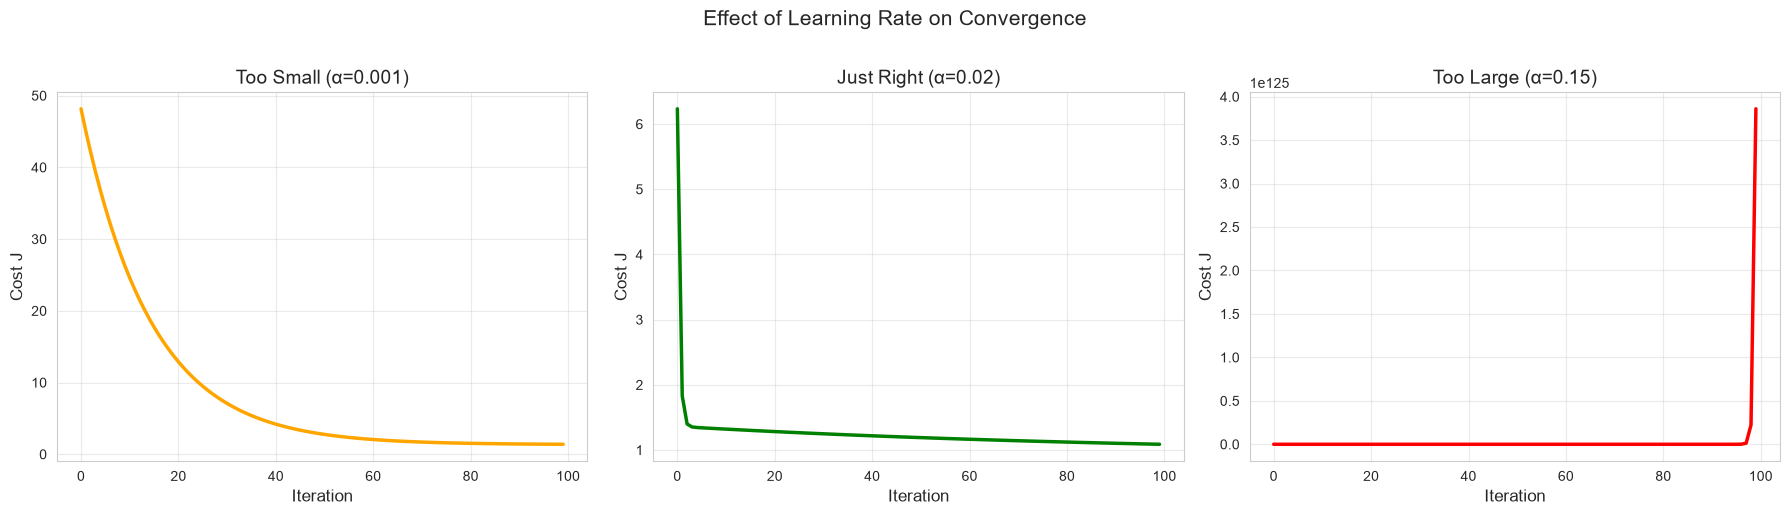

In [40]:
learning_rates = [0.001, 0.02, 0.15]
labels = ['Too Small (α=0.001)', 'Just Right (α=0.02)', 'Too Large (α=0.15)']
colors = ['orange', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (alpha, label, color) in enumerate(zip(learning_rates, labels, colors)):
    _, _, ch, _ = gradient_descent(X, y, alpha=alpha, iterations=100)
    axes[i].plot(ch, color=color, linewidth=2.5)
    axes[i].set_title(label)
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Cost J')
    axes[i].grid(True, alpha=0.4)

plt.suptitle('Effect of Learning Rate on Convergence', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

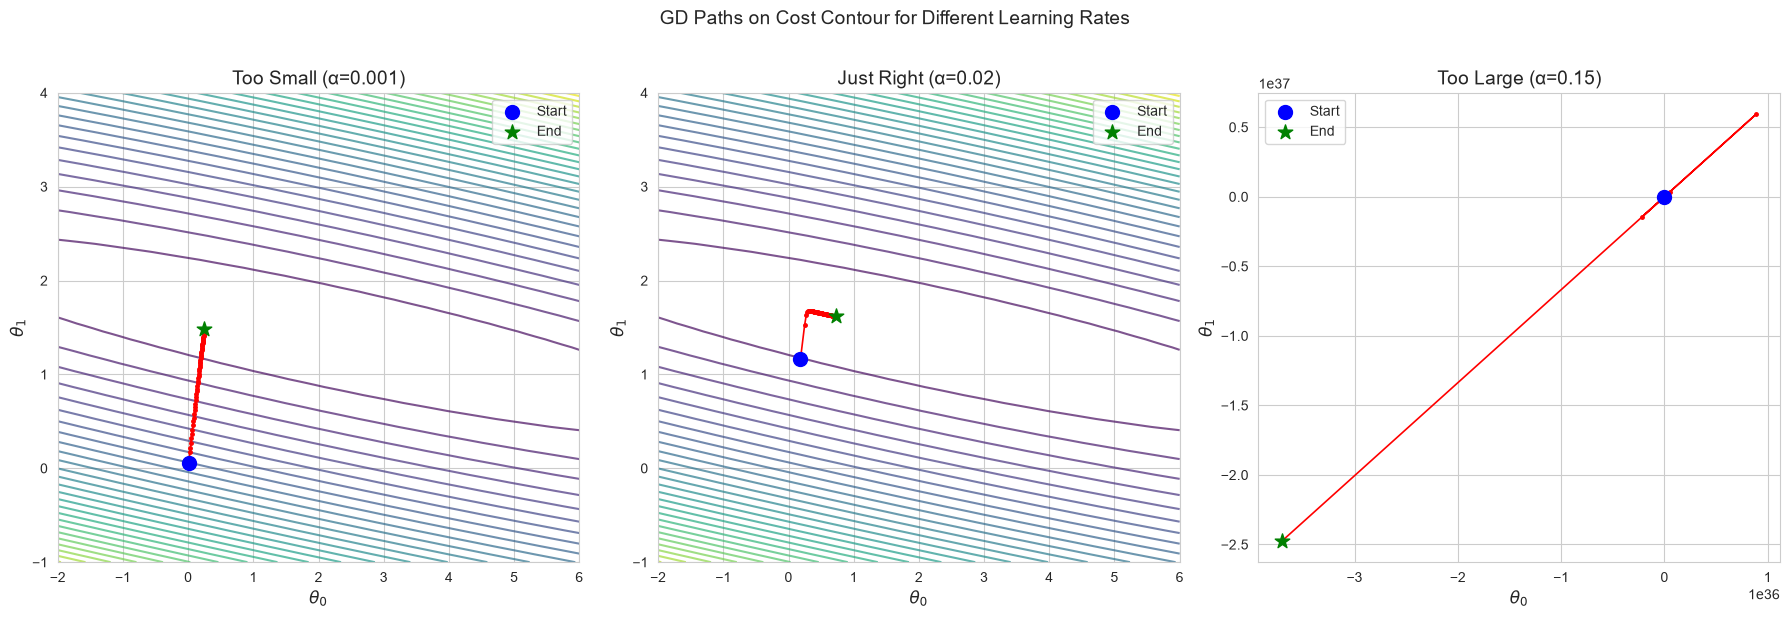

In [41]:
# Visualize the GD paths on contour for different learning rates
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (alpha, label) in enumerate(zip(learning_rates, labels)):
    _, _, _, th = gradient_descent(X, y, alpha=alpha, iterations=60)
    t0_p = [t[0] for t in th]
    t1_p = [t[1] for t in th]

    axes[i].contour(T0, T1, J_vals, levels=30, cmap=cm.viridis, alpha=0.7)
    axes[i].plot(t0_p, t1_p, 'r.-', markersize=5, linewidth=1.2)
    axes[i].scatter(t0_p[0], t1_p[0], color='blue', s=100, zorder=5, label='Start')
    axes[i].scatter(t0_p[-1], t1_p[-1], color='green', s=120, marker='*', zorder=5, label='End')
    axes[i].set_title(label)
    axes[i].set_xlabel(r'$\theta_0$')
    axes[i].set_ylabel(r'$\theta_1$')
    axes[i].legend()

plt.suptitle('GD Paths on Cost Contour for Different Learning Rates', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Convergence Plot (Cost vs Iterations)

When training works correctly, J should decrease monotonically until it plateaus.

### How to Read a Convergence Plot

- **Steep drop early, gradual flattening** → healthy training
- **Zig-zag / oscillating** → learning rate too high
- **Increasing** → learning rate way too high (divergence)
- **Very slow drop** → learning rate too low (increase α or wait longer)
- **Plateaus at high cost** → model may be underfitting (too simple, wrong features)

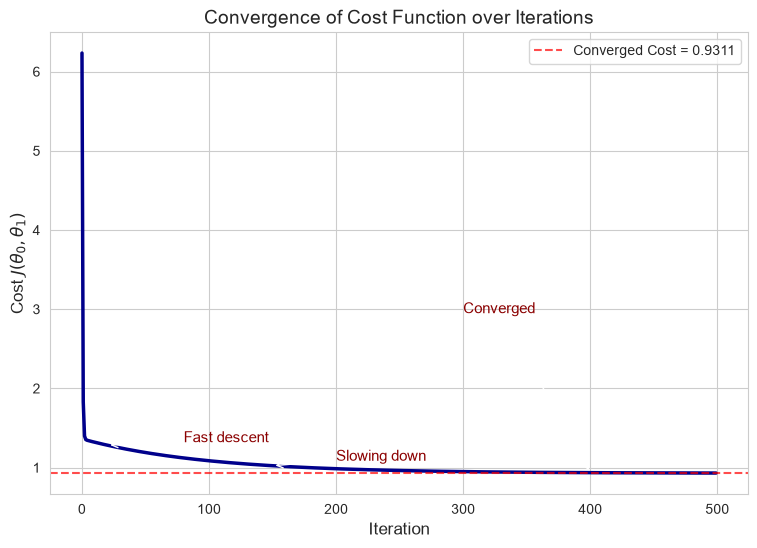

In [42]:
plt.figure(figsize=(9, 6))
plt.plot(cost_hist, color='darkblue', linewidth=2.5)
plt.title('Convergence of Cost Function over Iterations')
plt.xlabel('Iteration')
plt.ylabel(r'Cost $J(\theta_0, \theta_1)$')
plt.axhline(y=cost_hist[-1], color='red', linestyle='--', alpha=0.7,
            label=f'Converged Cost = {cost_hist[-1]:.4f}')

# Annotate three phases
plt.annotate('Fast descent', xy=(20, cost_hist[20]), xytext=(80, cost_hist[10]),
             arrowprops=dict(arrowstyle='->'), fontsize=11, color='darkred')
plt.annotate('Slowing down', xy=(150, cost_hist[150]), xytext=(200, cost_hist[100]),
             arrowprops=dict(arrowstyle='->'), fontsize=11, color='darkred')
plt.annotate('Converged', xy=(400, cost_hist[400]), xytext=(300, cost_hist[300]+2),
             arrowprops=dict(arrowstyle='->'), fontsize=11, color='darkred')

plt.legend()
plt.show()

C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


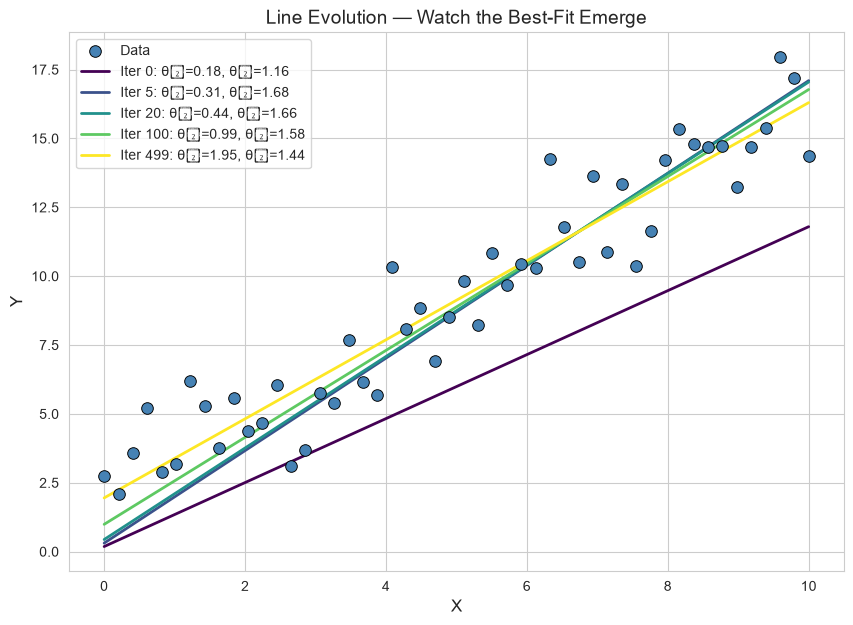

In [43]:
# Show how the line evolves during training
snapshots = [0, 5, 20, 100, 499]
colors_snap = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X, y=y, s=70, color='steelblue', edgecolor='black', label='Data', zorder=3)

for i, snap in enumerate(snapshots):
    t0, t1 = theta_hist[snap]
    y_line = t0 + t1 * X
    plt.plot(X, y_line, color=colors_snap[i], linewidth=2,
             label=f'Iter {snap}: θ₀={t0:.2f}, θ₁={t1:.2f}')

plt.title('Line Evolution — Watch the Best-Fit Emerge')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 8. Closed-Form Solution (Normal Equation / OLS)

For simple linear regression, we can solve analytically without gradient descent:

$$\theta_1 = \frac{\sum_{i=1}^{m}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{m}(x_i - \bar{x})^2}$$

$$\theta_0 = \bar{y} - \theta_1 \bar{x}$$

This is called **Ordinary Least Squares (OLS)** — it directly finds the θ values that make the derivative of J equal to zero.

### Gradient Descent vs OLS — When to Use Which?

| | Gradient Descent | OLS (Normal Equation) |
|---|---|---|
| Requires learning rate? | Yes | No |
| Iterations? | Many | One shot |
| Handles many features? | Yes, scales well | Slows down (matrix inverse O(n³)) |
| Works for non-linear models? | Yes | No — only linear |
| Best for | Big datasets, deep learning | Small datasets, exact solution |

### Hand-Calculated Example

In [44]:
X_ex = np.array([1, 2, 3, 4, 5])
y_ex = np.array([2, 4, 5, 4, 5])

x_mean_ex = X_ex.mean()
y_mean_ex = y_ex.mean()

df_ols = pd.DataFrame({
    'x': X_ex,
    'y': y_ex,
    'x - x̄': X_ex - x_mean_ex,
    'y - ȳ': y_ex - y_mean_ex,
    '(x-x̄)(y-ȳ)': (X_ex - x_mean_ex) * (y_ex - y_mean_ex),
    '(x-x̄)²': (X_ex - x_mean_ex) ** 2
})
print('Step-by-step OLS calculation:\n')
print(df_ols.to_string(index=False))

num = ((X_ex - x_mean_ex) * (y_ex - y_mean_ex)).sum()
den = ((X_ex - x_mean_ex) ** 2).sum()
theta1_ex = num / den
theta0_ex = y_mean_ex - theta1_ex * x_mean_ex

print(f'\nx̄ = {x_mean_ex}, ȳ = {y_mean_ex}')
print(f'Σ(x-x̄)(y-ȳ) = {num}')
print(f'Σ(x-x̄)² = {den}')
print(f'\nθ₁ = {num} / {den} = {theta1_ex}')
print(f'θ₀ = {y_mean_ex} - {theta1_ex} × {x_mean_ex} = {theta0_ex}')
print(f'\nBest-fit line: ŷ = {theta0_ex} + {theta1_ex}x')

Step-by-step OLS calculation:

 x  y  x - x̄  y - ȳ  (x-x̄)(y-ȳ)  (x-x̄)²
 1  2    -2.0   -2.0          4.0      4.0
 2  4    -1.0    0.0         -0.0      1.0
 3  5     0.0    1.0          0.0      0.0
 4  4     1.0    0.0          0.0      1.0
 5  5     2.0    1.0          2.0      4.0

x̄ = 3.0, ȳ = 4.0
Σ(x-x̄)(y-ȳ) = 6.0
Σ(x-x̄)² = 10.0

θ₁ = 6.0 / 10.0 = 0.6
θ₀ = 4.0 - 0.6 × 3.0 = 2.2

Best-fit line: ŷ = 2.2 + 0.6x


=== Closed-Form (OLS) Solution ===
θ₀ (intercept) = 2.0967
θ₁ (slope)     = 1.4130

=== Gradient Descent Solution ===
θ₀ (intercept) = 1.9492
θ₁ (slope)     = 1.4351

=== True (unknown) values used to generate data ===
θ₀ = 2.0, θ₁ = 1.5


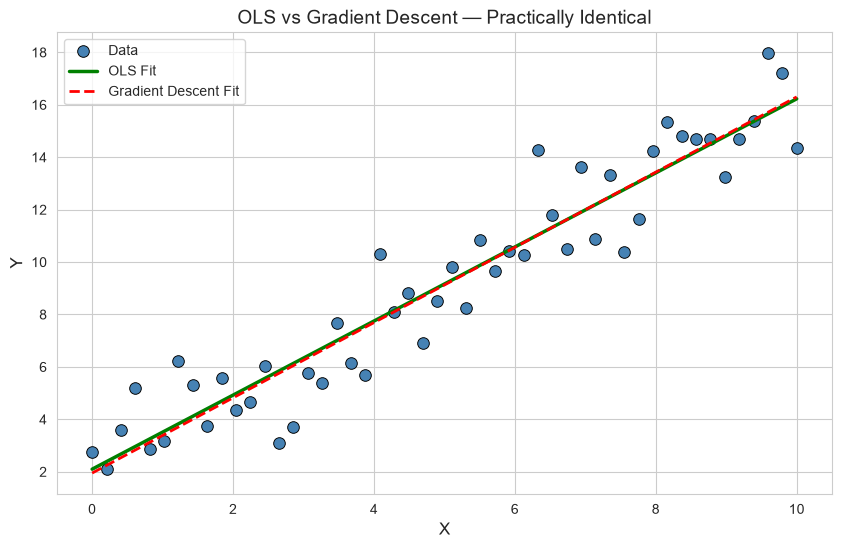

In [45]:
# Now do it on our full synthetic dataset
x_mean = np.mean(X)
y_mean = np.mean(y)

theta1_ols = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
theta0_ols = y_mean - theta1_ols * x_mean

print('=== Closed-Form (OLS) Solution ===')
print(f'θ₀ (intercept) = {theta0_ols:.4f}')
print(f'θ₁ (slope)     = {theta1_ols:.4f}')
print()
print('=== Gradient Descent Solution ===')
print(f'θ₀ (intercept) = {final_theta0:.4f}')
print(f'θ₁ (slope)     = {final_theta1:.4f}')
print()
print('=== True (unknown) values used to generate data ===')
print(f'θ₀ = {true_theta0}, θ₁ = {true_theta1}')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, s=70, color='steelblue', edgecolor='black', label='Data')
plt.plot(X, theta0_ols + theta1_ols * X, 'g-', linewidth=2.5, label='OLS Fit')
plt.plot(X, final_theta0 + final_theta1 * X, 'r--', linewidth=2, label='Gradient Descent Fit')
plt.title('OLS vs Gradient Descent — Practically Identical')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 9. Evaluation Metrics

How do we measure how good our model is? Several metrics:

### 9.1 MAE (Mean Absolute Error)

$$MAE = \frac{1}{m}\sum_{i=1}^m |y_i - \hat{y}_i|$$

- Average of absolute residuals
- Same units as Y — interpretable
- Less sensitive to outliers than MSE

### 9.2 MSE (Mean Squared Error)

$$MSE = \frac{1}{m}\sum_{i=1}^m (y_i - \hat{y}_i)^2$$

- Squared units of Y (harder to interpret)
- Penalizes large errors more heavily

### 9.3 RMSE (Root Mean Squared Error)

$$RMSE = \sqrt{MSE}$$

- Back to the units of Y
- Most commonly reported error metric

### 9.4 R² (Coefficient of Determination)

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **R² = 1** → perfect fit
- **R² = 0** → model no better than the mean
- **R² < 0** → worse than the mean
- Interpretation: "X explains R² × 100% of the variance in Y"

### 9.5 Adjusted R²

$$R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

Where n = samples, k = number of features. Penalizes adding useless features.

In [46]:
y_pred_final = theta0_ols + theta1_ols * X

mae = np.mean(np.abs(y - y_pred_final))
mse = np.mean((y - y_pred_final) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y - y_pred_final) ** 2)
ss_tot = np.sum((y - y_mean) ** 2)
r_squared = 1 - (ss_res / ss_tot)

n = len(y)
k = 1
adj_r_squared = 1 - ((1 - r_squared) * (n - 1)) / (n - k - 1)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²'],
    'Value': [f'{mae:.4f}', f'{mse:.4f}', f'{rmse:.4f}', f'{r_squared:.4f}', f'{adj_r_squared:.4f}'],
    'Interpretation': [
        'On average, off by this many units',
        'Mean of squared errors',
        'Typical error size in Y units',
        f'{r_squared*100:.2f}% of variance explained',
        'R² adjusted for # features'
    ]
})
print(metrics.to_string(index=False))

     Metric  Value                     Interpretation
        MAE 1.1118 On average, off by this many units
        MSE 1.8566             Mean of squared errors
       RMSE 1.3626      Typical error size in Y units
         R² 0.9032       90.32% of variance explained
Adjusted R² 0.9012         R² adjusted for # features


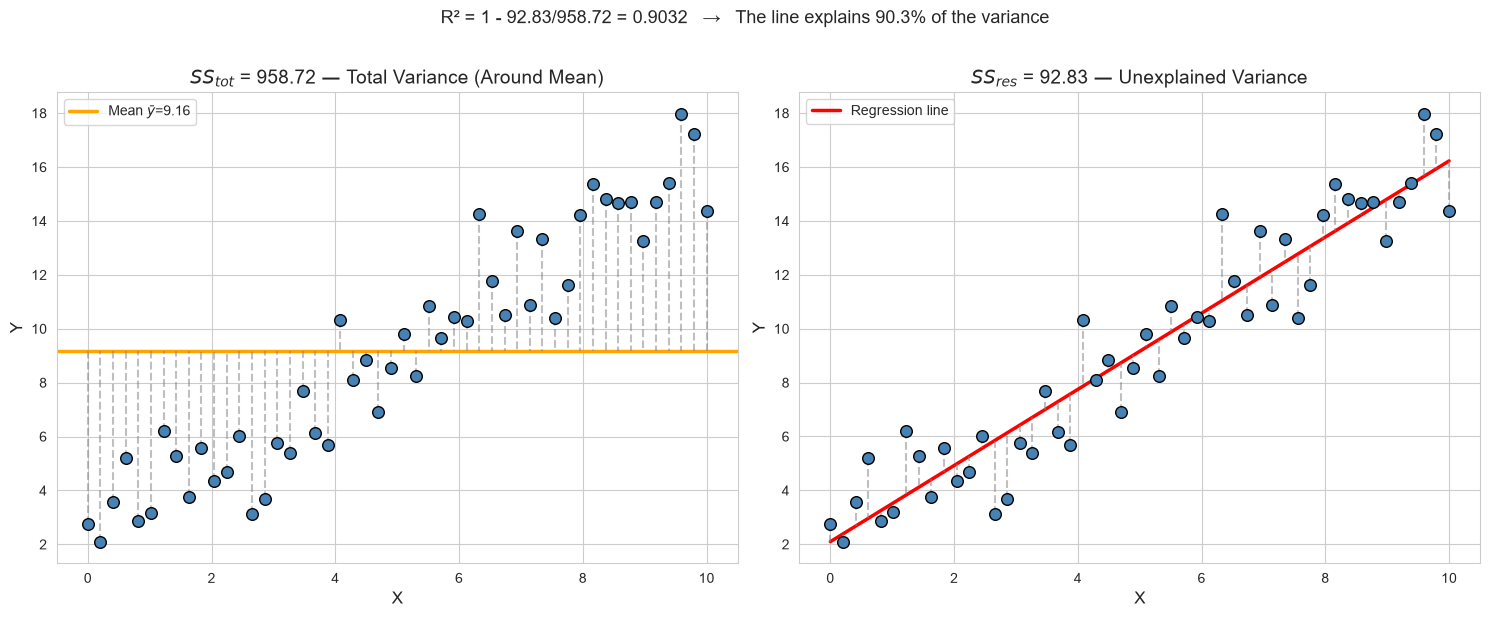

In [47]:
# Visualize SS_total vs SS_residual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X, y, s=70, color='steelblue', edgecolor='black', zorder=3)
axes[0].axhline(y=y_mean, color='orange', linewidth=2.5, label=f'Mean $\\bar{{y}}$={y_mean:.2f}')
for xi, yi in zip(X, y):
    axes[0].plot([xi, xi], [yi, y_mean], color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(fr'$SS_{{tot}}$ = {ss_tot:.2f} — Total Variance (Around Mean)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()

axes[1].scatter(X, y, s=70, color='steelblue', edgecolor='black', zorder=3)
axes[1].plot(X, y_pred_final, color='red', linewidth=2.5, label='Regression line')
for xi, yi, ypi in zip(X, y, y_pred_final):
    axes[1].plot([xi, xi], [yi, ypi], color='gray', linestyle='--', alpha=0.5)
axes[1].set_title(fr'$SS_{{res}}$ = {ss_res:.2f} — Unexplained Variance')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()

plt.suptitle(f'R² = 1 - {ss_res:.2f}/{ss_tot:.2f} = {r_squared:.4f}   →   The line explains {r_squared*100:.1f}% of the variance',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

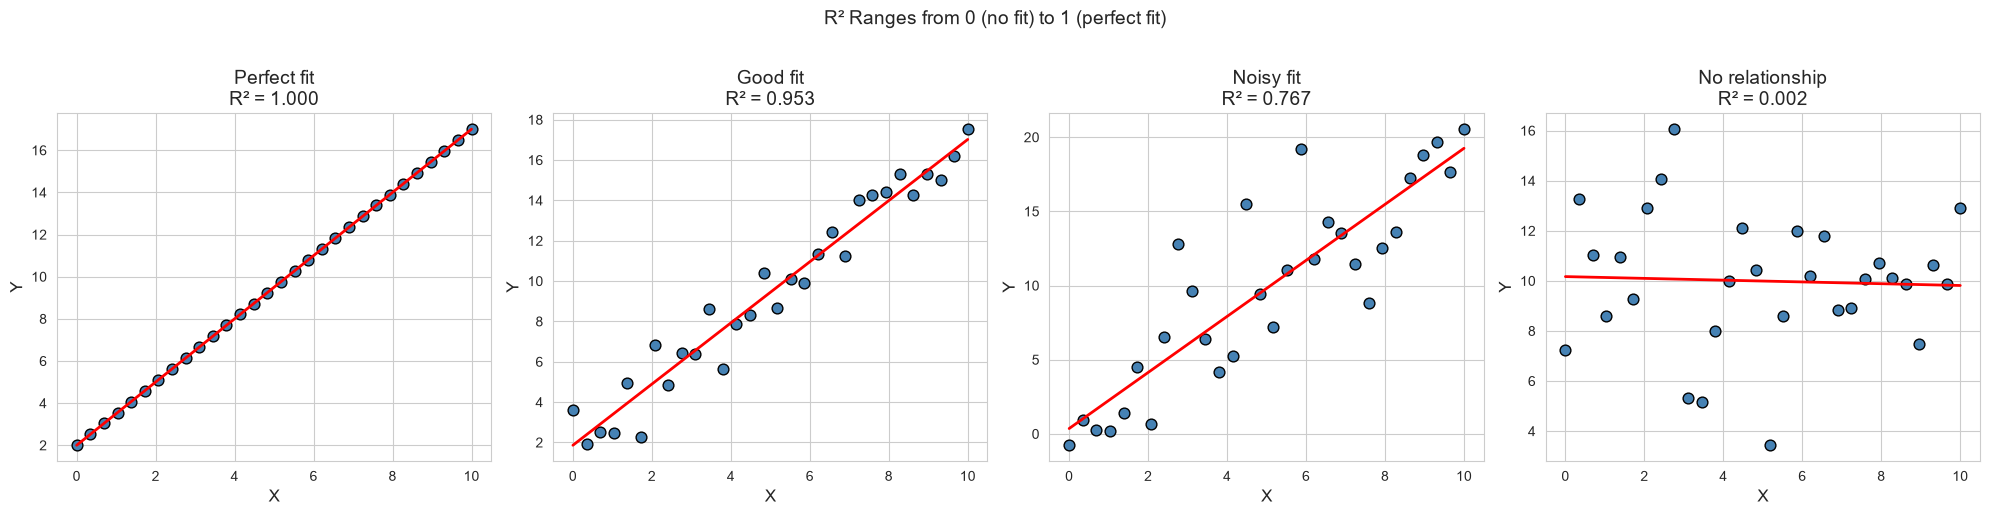

In [48]:
# Compare R² for different quality fits
np.random.seed(1)
X_demo = np.linspace(0, 10, 30)
y_perfect = 2 + 1.5 * X_demo
y_good = 2 + 1.5 * X_demo + np.random.normal(0, 1, 30)
y_noisy = 2 + 1.5 * X_demo + np.random.normal(0, 4, 30)
y_random = np.random.normal(y_perfect.mean(), 3, 30)

def r2(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cases = [
    (y_perfect, 'Perfect fit'),
    (y_good, 'Good fit'),
    (y_noisy, 'Noisy fit'),
    (y_random, 'No relationship')
]
for ax, (y_case, title) in zip(axes, cases):
    slope, intercept = np.polyfit(X_demo, y_case, 1)
    y_pred_case = intercept + slope * X_demo
    r2_val = r2(y_case, y_pred_case)
    ax.scatter(X_demo, y_case, s=60, color='steelblue', edgecolor='black')
    ax.plot(X_demo, y_pred_case, 'r-', linewidth=2)
    ax.set_title(f'{title}\nR² = {r2_val:.3f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('R² Ranges from 0 (no fit) to 1 (perfect fit)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Assumptions of Linear Regression

For linear regression's predictions and confidence intervals to be **valid**, five key assumptions should hold:

1. **Linearity** — The relationship between X and Y is actually linear (not curved)
2. **Independence** — Observations are independent (no time-series autocorrelation)
3. **Homoscedasticity** — Residuals have constant variance (spread is uniform)
4. **Normality of residuals** — Errors follow a normal distribution
5. **No multicollinearity** — (for multiple regression) features aren't correlated with each other

### How to Check Each

| Assumption | Diagnostic |
|---|---|
| Linearity | Scatter plot X vs Y; residuals vs fitted plot |
| Independence | Durbin-Watson test; know your data domain |
| Homoscedasticity | Residuals vs fitted plot — look for funnel shape |
| Normality | Histogram of residuals; Q-Q plot; Shapiro-Wilk test |
| Multicollinearity | VIF (Variance Inflation Factor); correlation matrix |

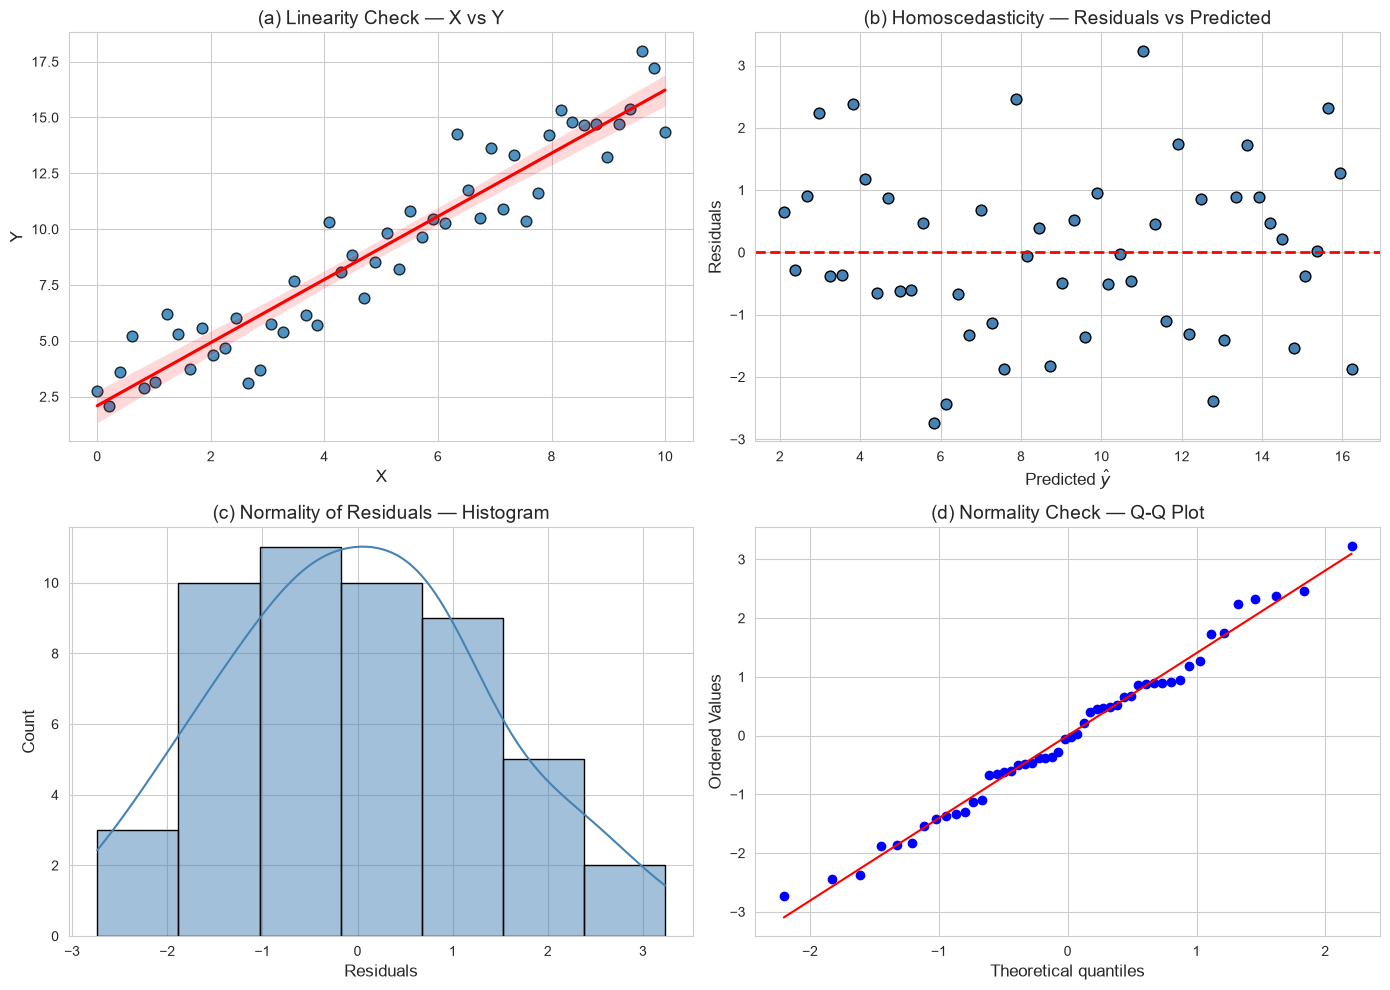

Shapiro-Wilk test: statistic = 0.9854, p-value = 0.7894
Interpretation: Residuals look normal (p > 0.05)


In [49]:
residuals = y - y_pred_final

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(x=X, y=y, ax=axes[0, 0], scatter_kws={'s': 60, 'edgecolor': 'black'}, line_kws={'color': 'red'})
axes[0, 0].set_title('(a) Linearity Check — X vs Y')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')

axes[0, 1].scatter(y_pred_final, residuals, s=60, color='steelblue', edgecolor='black')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('(b) Homoscedasticity — Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted $\\hat{y}$')
axes[0, 1].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_title('(c) Normality of Residuals — Histogram')
axes[1, 0].set_xlabel('Residuals')

stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('(d) Normality Check — Q-Q Plot')

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
stat, p = stats.shapiro(residuals)
print(f'Shapiro-Wilk test: statistic = {stat:.4f}, p-value = {p:.4f}')
print('Interpretation:', 'Residuals look normal (p > 0.05)' if p > 0.05 else 'Residuals may not be normal (p ≤ 0.05)')

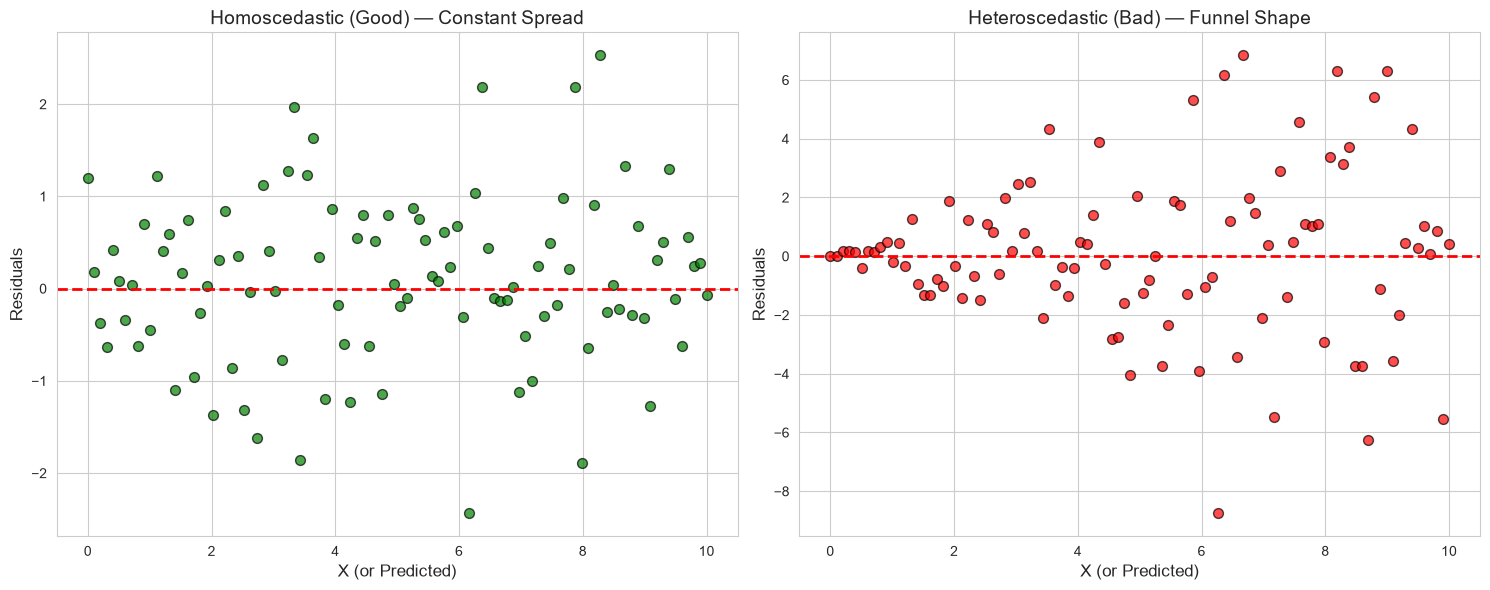

In [50]:
# Homoscedasticity vs Heteroscedasticity — side-by-side illustration
X_demo = np.linspace(0, 10, 100)
y_homo = 2 + 1.5 * X_demo + np.random.normal(0, 1.0, 100)
y_hetero = 2 + 1.5 * X_demo + np.random.normal(0, 0.5 * X_demo, 100)

res_homo = y_homo - (2 + 1.5 * X_demo)
res_hetero = y_hetero - (2 + 1.5 * X_demo)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_demo, res_homo, s=50, color='green', edgecolor='black', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Homoscedastic (Good) — Constant Spread')
axes[0].set_xlabel('X (or Predicted)')
axes[0].set_ylabel('Residuals')

axes[1].scatter(X_demo, res_hetero, s=50, color='red', edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Heteroscedastic (Bad) — Funnel Shape')
axes[1].set_xlabel('X (or Predicted)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 11. End-to-End Example — Salary Prediction from Years of Experience

Now let's put everything together with a realistic dataset.

In [51]:
# Realistic salary dataset
np.random.seed(0)
years_exp = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1,
                       4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5])
salary = np.array([39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
                    63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
                    91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872])

df = pd.DataFrame({'YearsExperience': years_exp, 'Salary': salary})
print('First 10 rows:')
print(df.head(10).to_string(index=False))
print(f'\nDataset shape: {df.shape}')
print(f'\nSummary statistics:')
print(df.describe().round(2))

First 10 rows:
 YearsExperience  Salary
             1.1   39343
             1.3   46205
             1.5   37731
             2.0   43525
             2.2   39891
             2.9   56642
             3.0   60150
             3.2   54445
             3.2   64445
             3.7   57189

Dataset shape: (30, 2)

Summary statistics:
       YearsExperience     Salary
count            30.00      30.00
mean              5.31   76003.00
std               2.84   27414.43
min               1.10   37731.00
25%               3.20   56720.75
50%               4.70   65237.00
75%               7.70  100544.75
max              10.50  122391.00


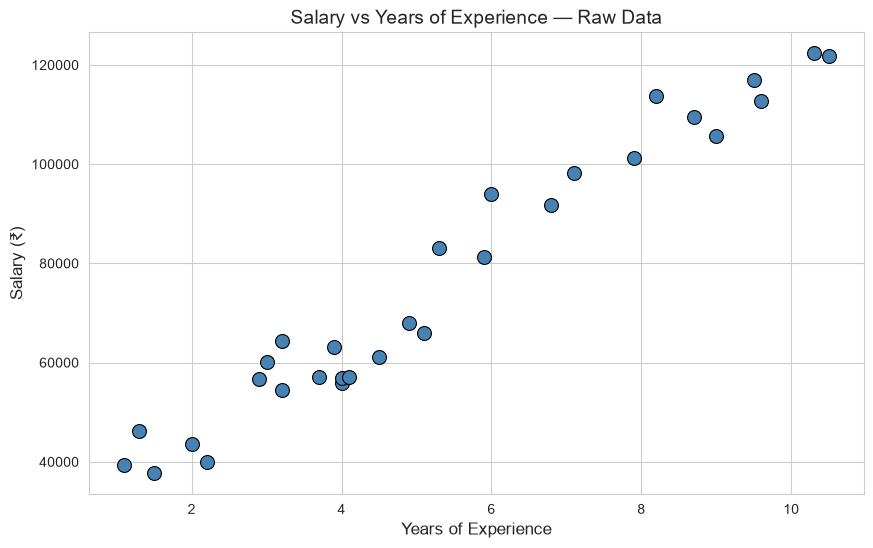

Correlation coefficient (r) = 0.9782
Strong positive relationship — a good candidate for linear regression!


In [52]:
# EDA — scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', s=100, color='steelblue', edgecolor='black')
plt.title('Salary vs Years of Experience — Raw Data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (₹)')
plt.show()

# Correlation
corr = df['YearsExperience'].corr(df['Salary'])
print(f'Correlation coefficient (r) = {corr:.4f}')
print(f'Strong positive relationship — a good candidate for linear regression!')

In [53]:
# Fit using OLS (closed-form)
X_sal = df['YearsExperience'].values
y_sal = df['Salary'].values

x_bar = X_sal.mean()
y_bar = y_sal.mean()

theta1_sal = np.sum((X_sal - x_bar) * (y_sal - y_bar)) / np.sum((X_sal - x_bar) ** 2)
theta0_sal = y_bar - theta1_sal * x_bar

print('=== Fitted Model ===')
print(f'θ₀ (base salary)  = ₹{theta0_sal:,.2f}')
print(f'θ₁ (₹ per year)   = ₹{theta1_sal:,.2f}')
print(f'\nEquation: Salary = ₹{theta0_sal:,.0f} + ₹{theta1_sal:,.0f} × Years')

# Predictions & metrics
y_pred_sal = theta0_sal + theta1_sal * X_sal
mae_sal = np.mean(np.abs(y_sal - y_pred_sal))
rmse_sal = np.sqrt(np.mean((y_sal - y_pred_sal) ** 2))
r2_sal = 1 - np.sum((y_sal - y_pred_sal)**2) / np.sum((y_sal - y_bar)**2)

print(f'\n=== Model Performance ===')
print(f'MAE  = ₹{mae_sal:,.2f}')
print(f'RMSE = ₹{rmse_sal:,.2f}')
print(f'R²   = {r2_sal:.4f}   ({r2_sal*100:.2f}% of salary variance explained by experience)')

=== Fitted Model ===
θ₀ (base salary)  = ₹25,792.20
θ₁ (₹ per year)   = ₹9,449.96

Equation: Salary = ₹25,792 + ₹9,450 × Years

=== Model Performance ===
MAE  = ₹4,644.20
RMSE = ₹5,592.04
R²   = 0.9570   (95.70% of salary variance explained by experience)


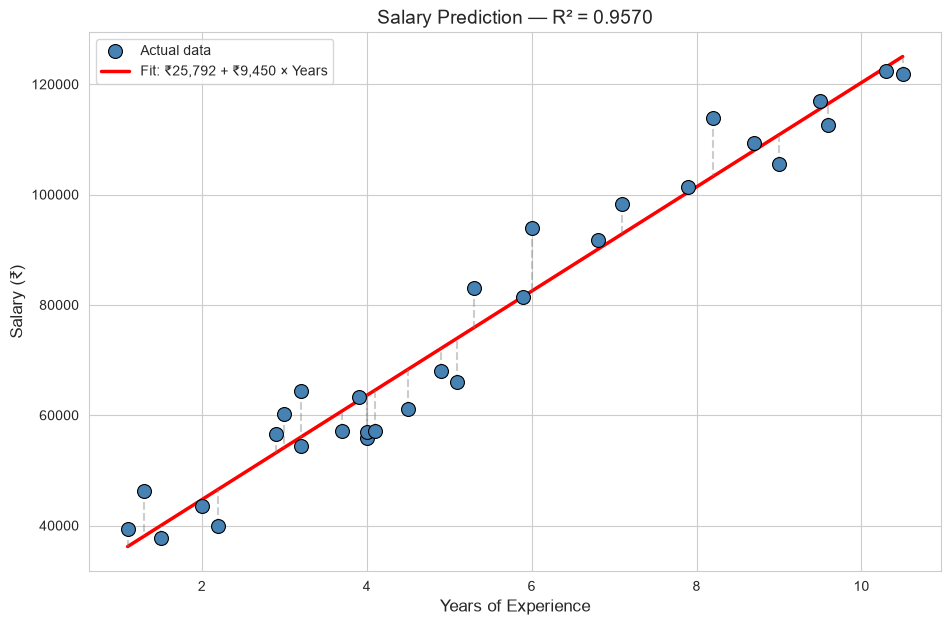

In [54]:
# Plot the fit
plt.figure(figsize=(11, 7))
sns.scatterplot(x=X_sal, y=y_sal, s=100, color='steelblue', edgecolor='black', label='Actual data', zorder=3)
plt.plot(X_sal, y_pred_sal, 'r-', linewidth=2.5, label=f'Fit: ₹{theta0_sal:,.0f} + ₹{theta1_sal:,.0f} × Years')

for xi, yi, ypi in zip(X_sal, y_sal, y_pred_sal):
    plt.plot([xi, xi], [yi, ypi], color='gray', linestyle='--', alpha=0.4)

plt.title(f'Salary Prediction — R² = {r2_sal:.4f}')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (₹)')
plt.legend()
plt.show()

In [55]:
# Predict for new candidates
print('=== Predictions for New Candidates ===\n')
for exp in [0, 1.5, 4, 6.5, 8, 12, 15]:
    pred = theta0_sal + theta1_sal * exp
    warn = '  ← extrapolation, be cautious' if exp > df['YearsExperience'].max() else ''
    print(f'  {exp:5.1f} years of experience → Predicted salary = ₹{pred:>12,.2f}{warn}')

=== Predictions for New Candidates ===

    0.0 years of experience → Predicted salary = ₹   25,792.20
    1.5 years of experience → Predicted salary = ₹   39,967.14
    4.0 years of experience → Predicted salary = ₹   63,592.05
    6.5 years of experience → Predicted salary = ₹   87,216.96
    8.0 years of experience → Predicted salary = ₹  101,391.90
   12.0 years of experience → Predicted salary = ₹  139,191.75  ← extrapolation, be cautious
   15.0 years of experience → Predicted salary = ₹  167,541.64  ← extrapolation, be cautious


## 12. Comparison with sklearn

In practice you use `sklearn.linear_model.LinearRegression`. Let's verify our from-scratch results match.

In [56]:
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    model = LinearRegression()
    model.fit(X_sal.reshape(-1, 1), y_sal)

    y_pred_sk = model.predict(X_sal.reshape(-1, 1))

    print('=== sklearn Results ===')
    print(f'Intercept θ₀ = ₹{model.intercept_:,.2f}')
    print(f'Slope     θ₁ = ₹{model.coef_[0]:,.2f}')
    print(f'MAE  = ₹{mean_absolute_error(y_sal, y_pred_sk):,.2f}')
    print(f'RMSE = ₹{np.sqrt(mean_squared_error(y_sal, y_pred_sk)):,.2f}')
    print(f'R²   = {r2_score(y_sal, y_pred_sk):.4f}')

    print('\n=== Our From-Scratch Results ===')
    print(f'Intercept θ₀ = ₹{theta0_sal:,.2f}')
    print(f'Slope     θ₁ = ₹{theta1_sal:,.2f}')
    print(f'MAE  = ₹{mae_sal:,.2f}')
    print(f'RMSE = ₹{rmse_sal:,.2f}')
    print(f'R²   = {r2_sal:.4f}')
    print('\nBoth match perfectly (up to floating-point precision).')
except ImportError:
    print('sklearn not installed — run: pip install scikit-learn')

=== sklearn Results ===
Intercept θ₀ = ₹25,792.20
Slope     θ₁ = ₹9,449.96
MAE  = ₹4,644.20
RMSE = ₹5,592.04
R²   = 0.9570

=== Our From-Scratch Results ===
Intercept θ₀ = ₹25,792.20
Slope     θ₁ = ₹9,449.96
MAE  = ₹4,644.20
RMSE = ₹5,592.04
R²   = 0.9570

Both match perfectly (up to floating-point precision).


## Summary Table — All Key Formulas

| Concept | Formula |
|---|---|
| Hypothesis | $\hat{y} = \theta_0 + \theta_1 x$ |
| Residual | $e_i = y_i - \hat{y}_i$ |
| Cost Function | $J = \frac{1}{2m} \sum (\hat{y} - y)^2$ |
| Gradient (θ₀) | $\frac{1}{m} \sum (\hat{y} - y)$ |
| Gradient (θ₁) | $\frac{1}{m} \sum (\hat{y} - y) \cdot x$ |
| Update Rule | $\theta := \theta - \alpha \cdot \frac{\partial J}{\partial \theta}$ |
| Closed-Form Slope | $\frac{\sum (x - \bar{x})(y - \bar{y})}{\sum (x - \bar{x})^2}$ |
| Closed-Form Intercept | $\bar{y} - \theta_1 \bar{x}$ |
| MAE | $\frac{1}{m} \sum \|y - \hat{y}\|$ |
| MSE | $\frac{1}{m} \sum (y - \hat{y})^2$ |
| RMSE | $\sqrt{MSE}$ |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ |
| Adjusted R² | $1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$ |

---

### Key Takeaways

1. Simple linear regression fits **ŷ = θ₀ + θ₁x** to model a linear relationship.
2. The **MSE cost function** is convex, meaning gradient descent will always find the global minimum.
3. **Gradient descent** iteratively updates parameters using the derivative of the cost.
4. The **learning rate α** is the most critical hyperparameter — too small = slow, too big = diverge.
5. For simple linear regression, the **closed-form (OLS) solution** gives the answer in one shot.
6. Evaluate using **R²** (variance explained) and **RMSE** (typical error size).
7. Always check the **5 assumptions** — especially with a residuals plot.
8. **Extrapolation is risky** — the model only knows what it saw during training.

---

### Next Steps
- **Multiple Linear Regression** — extend to many features
- **Polynomial Regression** — capture non-linear patterns
- **Regularization** (Ridge, Lasso, ElasticNet) — control overfitting
- **Train/Test split & Cross-Validation** — proper model evaluation